## <strong>9. RESTful API를 이용한 데이터 취득</strong>

In [15]:
import requests  # HTTP 통신 라이브러리
import matplotlib.pyplot as plt # 데이터 시각화
import time # API 요청 제한(Rate Limit) 우회를 위한 시간 제어

In [16]:
# 1. 상위 100개 코인 정보 가져오기 (Data Acquisition 단계)
def get_top_100_coins():
    """
    CoinGecko API를 통해 시장의 원천 데이터(Raw Data)를 취득
    """
    url = "https://api.coingecko.com/api/v3/coins/markets"
    
    # API 요청 파라미터 설정
    params = {
        "vs_currency": "usd",        # 통화 단위: USD
        "order": "market_cap_desc",  # 정렬 기준: 시가총액 내림차순
        "per_page": 100,             # 취득할 데이터 양: 100개
        "page": 1,                   # 페이지 번호
        "sparkline": False           # 데이터 부하를 줄이기 위해 그래프 데이터 제외
    }
    
    # RESTful API 호출 (HTTP GET 방식)
    response = requests.get(url, params=params)
    
    # 응답받은 JSON 데이터를 파이썬 객체로 변환
    return response.json()

In [17]:
# 2. 특정 코인의 시가총액 추이 가져오기
def get_market_chart(coin_id):
    """
    특정 코인의 ID를 사용하여 시계열 데이터를 요청
    """
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {
        "vs_currency": "usd",
        "days": 365,          # 데이터 범위: 최근 365일
        "interval": "daily"   # 데이터 간격: 일 단위 (데이터 정제 과정)
    }
    
    response = requests.get(url, params=params)
    
    # HTTP 상태 코드가 200(성공)일 경우에만 데이터 반환 (예외 처리)
    if response.status_code == 200:
        return response.json()["market_caps"]
    else:
        # 데이터 취득 실패 시 빈 리스트 반환
        return []

In [18]:
# 3. 시각화 함수 
def plot_market_caps(coin_data):
    """
    가공된 데이터를 바탕으로 분석용 차트를 생성
    """
    plt.figure(figsize=(16, 10))

    for coin_name, market_caps in coin_data.items():
        if not market_caps:
            continue
            
        timestamps = [cap[0] for cap in market_caps] # x축: 타임스탬프
        
        # 데이터 스케일링: 가독성을 위해 달러 단위를 10억(Billion) 단위로 변환
        values = [cap[1] / 1e9 for cap in market_caps] 
        
        plt.plot(timestamps, values, label=coin_name)

    # 시각화
    plt.title("Top 100 Alt Coins - Market Cap Trend (Last 365 Days)")
    plt.xlabel("Timestamp")
    plt.ylabel("Market Cap (Billion USD)")
    plt.xticks(rotation=45)
    plt.legend(fontsize="small", loc="upper left", ncol=2)
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [23]:
# --- 메인 실행 흐름 ---

print("🚀 상위 100개 코인 정보를 불러오는 중...")
all_coins = get_top_100_coins()

# 데이터 필터링: 시장 지배력이 너무 큰 BTC, ETH를 제외하여 주요 알트코인들의 추이를 비교
coins = all_coins[2:] 

coin_market_data = {}

# 반복문을 통한 대량 데이터 취득
for i, coin in enumerate(coins):
    coin_id = coin["id"]
    coin_name = coin["name"]
    
    print(f"📈 데이터 수집 중: {coin_name} ({i+1}/100)")
    market_caps = get_market_chart(coin_id)
    
    # 딕셔너리에 데이터 적재
    coin_market_data[coin_name] = market_caps
    
    # API 요청 제한 우회
    time.sleep(1.2) 

    # 실습 효율을 위해 상위 4개 알트코인만 수집 후 중단
    if i >= 3: 
        break

🚀 상위 100개 코인 정보를 불러오는 중...


KeyError: slice(2, None, None)

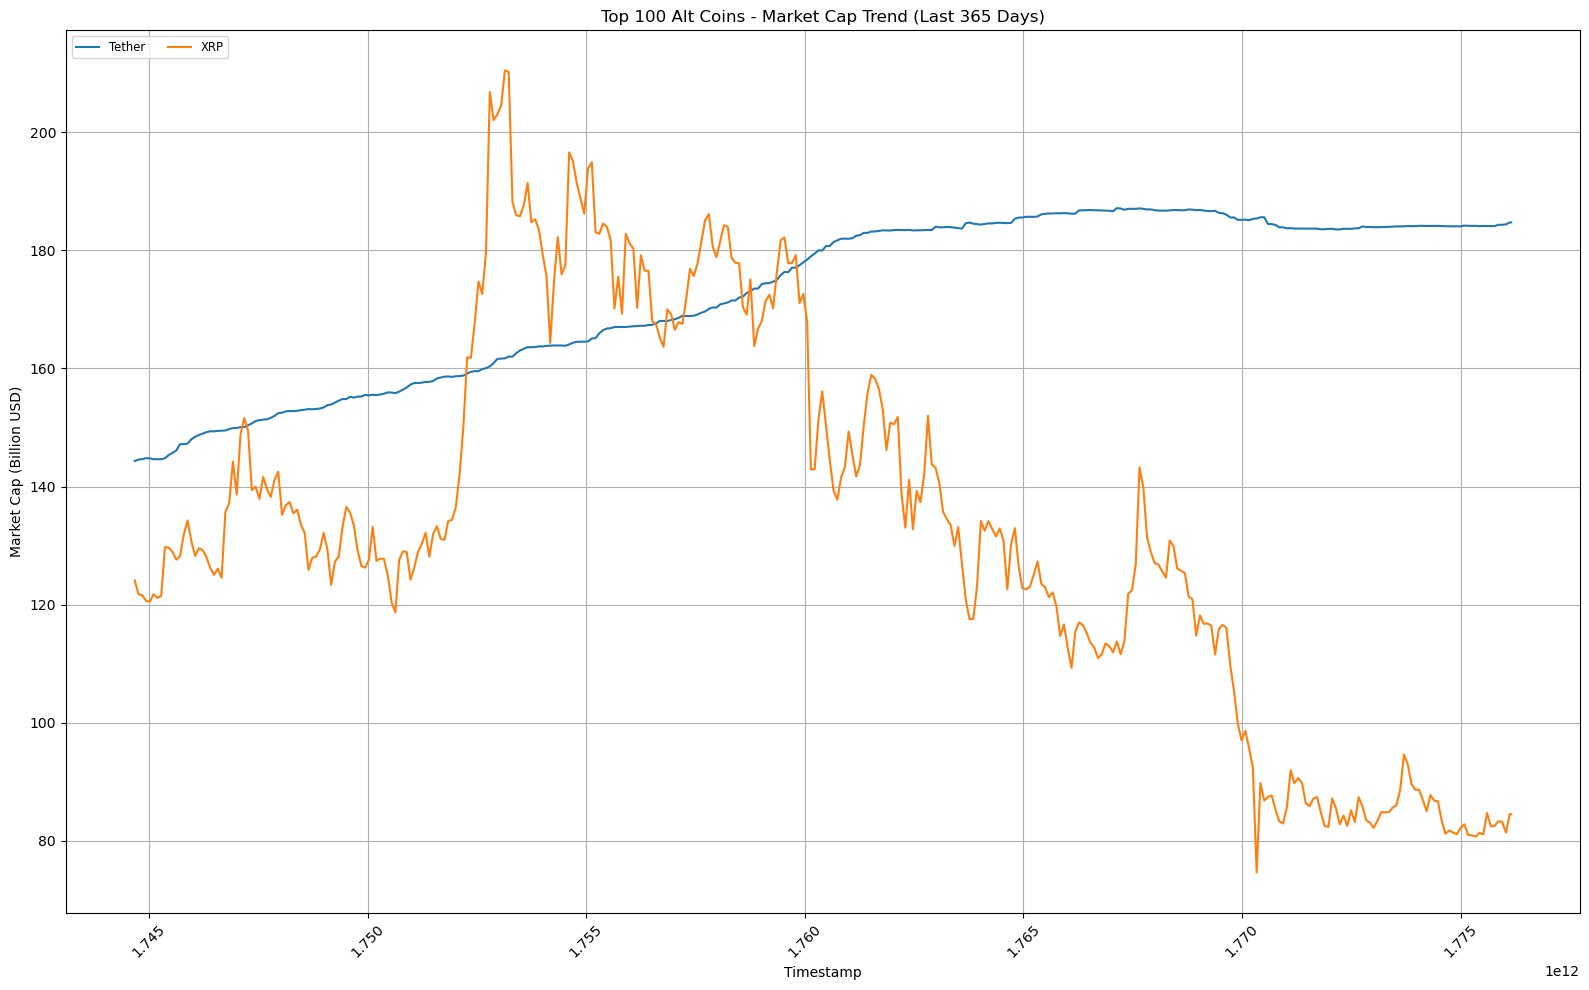

In [7]:
# 최종 가공된 데이터를 시각화
plot_market_caps(coin_market_data)

In [20]:
# get_top_100_coins() 응답 내용(JSON) 확인
coins

[{'id': 'tether',
  'symbol': 'usdt',
  'name': 'Tether',
  'image': 'https://coin-images.coingecko.com/coins/images/325/large/Tether.png?1696501661',
  'current_price': 1.0,
  'market_cap': 184734844167,
  'market_cap_rank': 3,
  'fully_diluted_valuation': 190203572472,
  'total_volume': 91419466367,
  'high_24h': 1.0,
  'low_24h': 0.999792,
  'price_change_24h': 0.00029886,
  'price_change_percentage_24h': 0.02989,
  'market_cap_change_24h': 286582122,
  'market_cap_change_percentage_24h': 0.15537,
  'circulating_supply': 184674430497.4122,
  'total_supply': 190141370368.7762,
  'max_supply': None,
  'ath': 1.32,
  'ath_change_percentage': -24.39163,
  'ath_date': '2018-07-24T00:00:00.000Z',
  'atl': 0.572521,
  'atl_change_percentage': 74.73085,
  'atl_date': '2015-03-02T00:00:00.000Z',
  'roi': None,
  'last_updated': '2026-04-14T09:17:38.085Z'},
 {'id': 'ripple',
  'symbol': 'xrp',
  'name': 'XRP',
  'image': 'https://coin-images.coingecko.com/coins/images/44/large/xrp-symbol-whit

In [43]:
# get_market_chart() 응답 내용(JSON) 확인
coin_market_data

{'Tether': [[1744675200000, 144334107980.62497],
  [1744761600000, 144568505877.0596],
  [1744848000000, 144632716534.40927],
  [1744934400000, 144806058274.99985],
  [1745020800000, 144773493164.272],
  [1745107200000, 144626535181.3877],
  [1745193600000, 144636655192.65256],
  [1745280000000, 144628467100.05707],
  [1745366400000, 144787216371.0264],
  [1745452800000, 145334994442.8229],
  [1745539200000, 145704892662.22678],
  [1745625600000, 146102824559.95065],
  [1745712000000, 147176227949.38904],
  [1745798400000, 147177522305.55164],
  [1745884800000, 147276031291.01443],
  [1745971200000, 148006012381.16373],
  [1746057600000, 148428458921.78488],
  [1746144000000, 148729502512.55002],
  [1746230400000, 148960089669.36575],
  [1746316800000, 149216918792.02405],
  [1746403200000, 149359909126.67517],
  [1746489600000, 149346610972.1294],
  [1746576000000, 149419951385.11246],
  [1746662400000, 149457054005.27136],
  [1746748800000, 149493872634.72855],
  [1746835200000, 1497